## Aumento de datos

Este notebook presenta un ejemplo práctico de **aumento de datos (data augmentation)** aplicado a imágenes, utilizando la clase `ImageDataGenerator` de Keras. A partir de una imagen de entrada, se aplican diversas transformaciones típicas en el preprocesamiento de datos para tareas de visión por computadora, tales como:

- Rotación
- Desplazamiento horizontal y vertical
- Zoom
- Volteo (flip) horizontal

Cada transformación es visualizada para facilitar la comprensión de su efecto sobre la imagen original. Este procedimiento es especialmente útil para **incrementar la diversidad del conjunto de entrenamiento** y mejorar la **capacidad de generalización** de modelos de aprendizaje profundo, sin necesidad de recolectar nuevas muestras.

Este enfoque es común en tareas como clasificación de imágenes, detección de objetos y segmentación semántica.


In [1]:
!ls test

ls: cannot access 'test': No such file or directory


In [2]:
# Librerias de ayuda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2 as cv
from numpy import random

In [9]:
imagen_test='perro_gato.png'

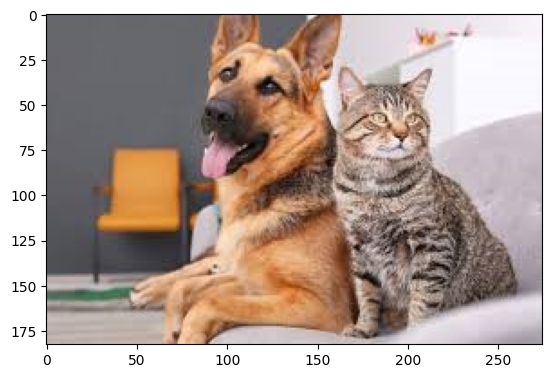

In [10]:
img = cv.imread(imagen_test)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB) , cmap="binary")

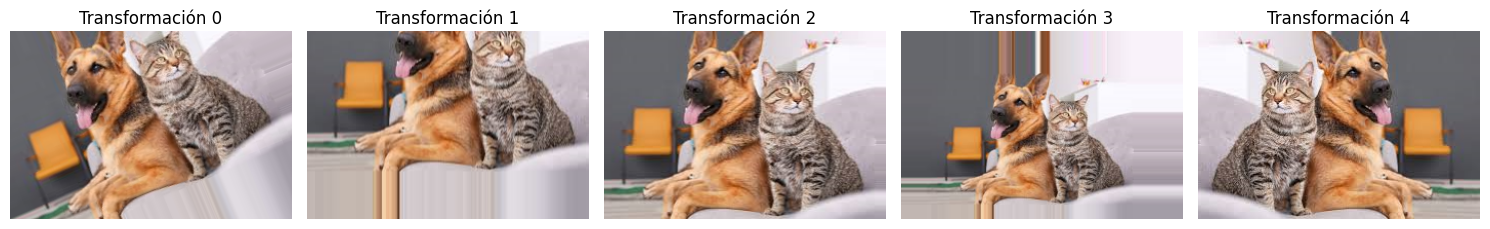

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

# Cargar la imagen
img = load_img(imagen_test)
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Añade dimensión de batch

# Diccionario con transformaciones individuales
transformaciones = {
    "Rotación (45°)": ImageDataGenerator(rotation_range=45),
    "Desplazamiento horizontal (35%)": ImageDataGenerator(width_shift_range=0.35),
    "Desplazamiento vertical (30%)": ImageDataGenerator(height_shift_range=0.30),
    "Zoom (50%)": ImageDataGenerator(zoom_range=0.5),
    "Flip horizontal": ImageDataGenerator(horizontal_flip=True)
}

# Visualizar cada transformación
plt.figure(figsize=(15, 5))
for i, (titulo, generator) in enumerate(transformaciones.items()):
    aug_iter = generator.flow(img_array, batch_size=1)
    imagen_transformada = next(aug_iter)[0].astype("uint8")

    # Mostrar cada imagen transformada
    plt.subplot(1, 5, i + 1)
    plt.imshow(imagen_transformada)
    plt.title('Transformación '+str(i))
    plt.axis('off')

plt.tight_layout()
plt.show()

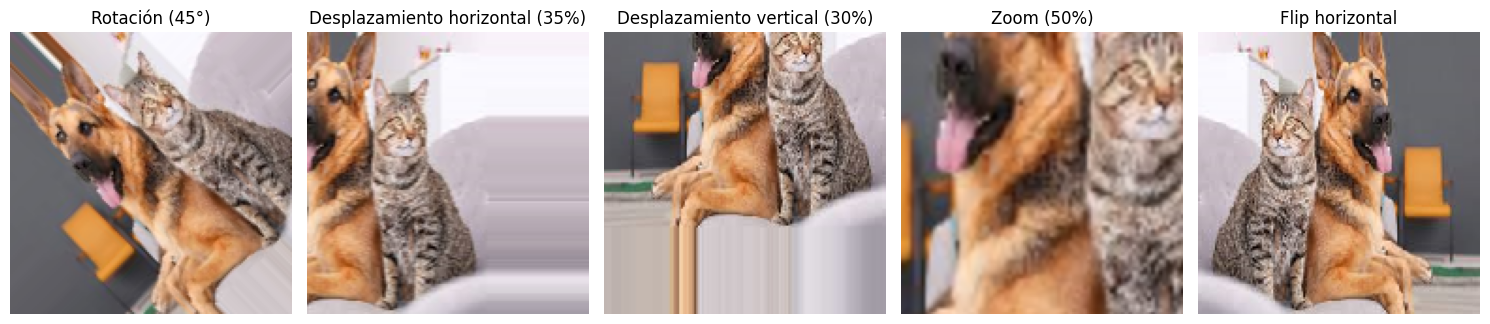

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

# Cargar la imagen
imagen_test='perro_gato.png'
img = load_img(imagen_test, target_size=(150,150))
img_array = img_to_array(img)

# Crear un generador base (sin aleatoriedad)
datagen = ImageDataGenerator()

# Diccionario con transformaciones fijas
transformaciones = {
    "Rotación (45°)": {'theta': 45},
    "Desplazamiento horizontal (35%)": {'tx': 0.35 * img_array.shape[1]},  # píxeles
    "Desplazamiento vertical (30%)": {'ty': 0.30 * img_array.shape[0]},    # píxeles
    "Zoom (50%)": {'zx': 0.5, 'zy': 0.5},  # agrandar 50%
    "Flip horizontal": {'flip_horizontal': True}
}

# Mostrar resultados
plt.figure(figsize=(15, 5))

for i, (titulo, params) in enumerate(transformaciones.items()):
    imagen_transformada = datagen.apply_transform(img_array, params)
    plt.subplot(1, 5, i + 1)
    plt.imshow(imagen_transformada.astype("uint8"))
    plt.title(titulo)
    plt.axis('off')

plt.tight_layout()
plt.show()


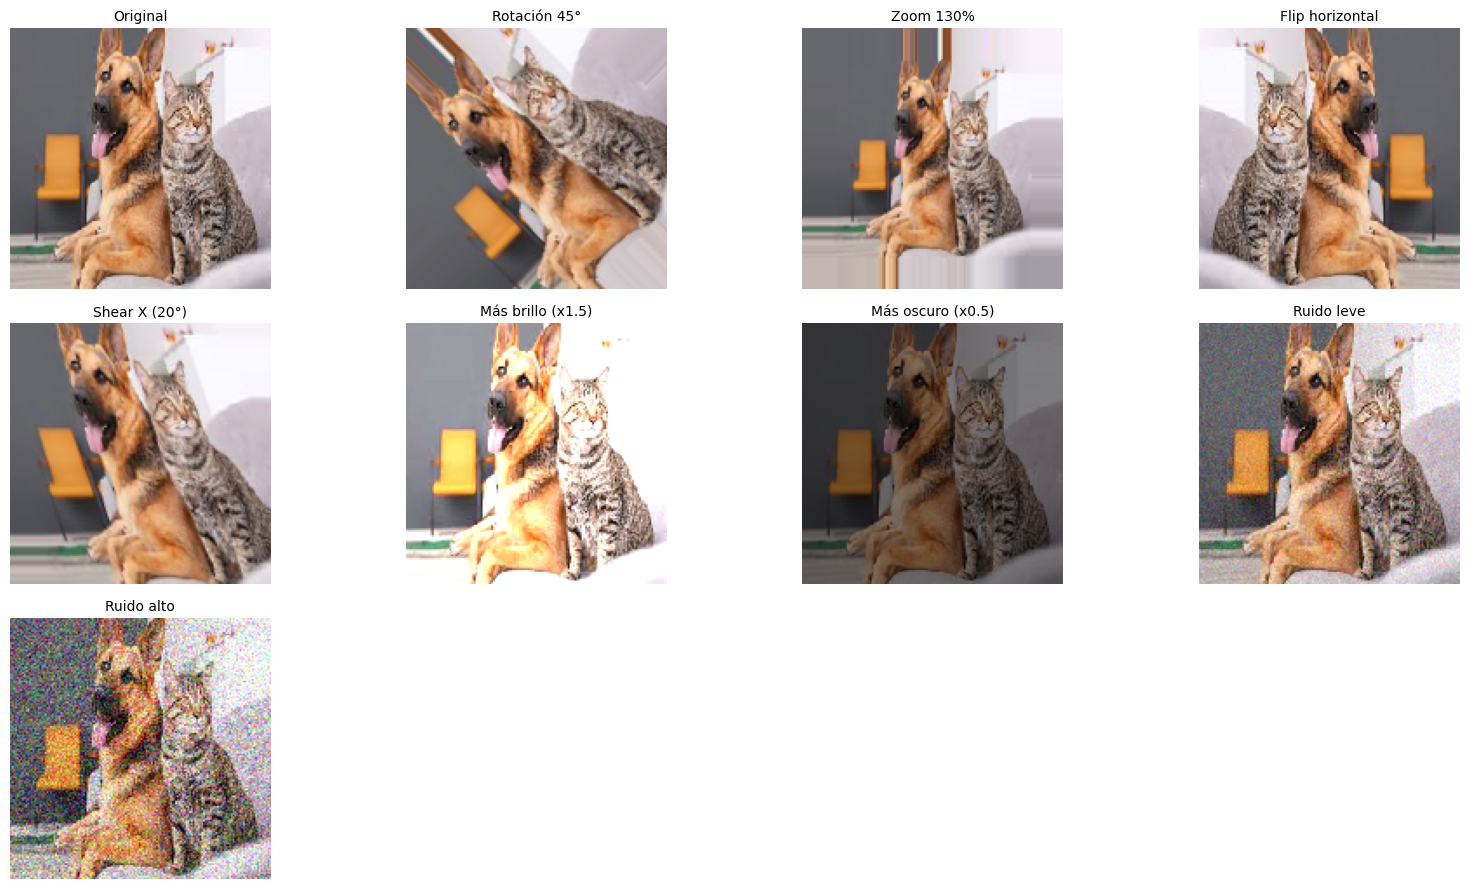

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

# Cargar la imagen
imagen_test='perro_gato.png'
img = load_img(imagen_test, target_size=(150,150))
img_array = img_to_array(img)

# Generador base
datagen = ImageDataGenerator()

# Función para agregar ruido gaussiano
def add_noise(img, noise_level=0.1):
    noise = np.random.normal(0, noise_level * 255, img.shape)
    noisy_img = np.clip(img + noise, 0, 255)
    return noisy_img

# 📸 Transformaciones fijas
transformaciones = {
    "Original": {},
    "Rotación 45°": {'theta': 45},
    "Zoom 130%": {'zx': 1.3, 'zy': 1.3},
    "Flip horizontal": {'flip_horizontal': True},
    "Shear X (20°)": {'shear': 20},

    # Ajustes de iluminación (manual)
    "Más brillo (x1.5)": "brighten",
    "Más oscuro (x0.5)": "darken",

    # Ruido
    "Ruido leve": "noise_low",
    "Ruido alto": "noise_high"
}

# Mostrar resultados
n = len(transformaciones)
cols = 4
rows = int(np.ceil(n / cols))

plt.figure(figsize=(16, rows * 3))

for i, (titulo, params) in enumerate(transformaciones.items()):
    if params == {}:
        img_out = img_array
    elif params == "brighten":
        img_out = np.clip(img_array * 1.5, 0, 255)
    elif params == "darken":
        img_out = np.clip(img_array * 0.5, 0, 255)
    elif params == "noise_low":
        img_out = add_noise(img_array, noise_level=0.05)
    elif params == "noise_high":
        img_out = add_noise(img_array, noise_level=0.15)
    else:
        img_out = datagen.apply_transform(img_array, params)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_out.astype("uint8"))
    plt.title(titulo, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


# Imagenes de piedra, papel y tijera

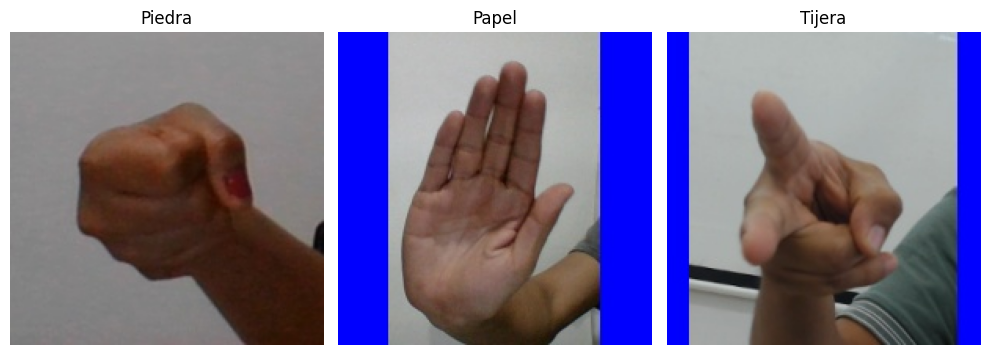

In [20]:
# Cargar las imágenes locales
imagenes = ['test/piedra.jpg', 'test/papel.jpg', 'test/tijera.jpg']
nombres = ['Piedra', 'Papel', 'Tijera']

# Mostrar las imágenes originales
plt.figure(figsize=(10, 5))
for i, (img_path, nombre) in enumerate(zip(imagenes, nombres)):
    img = load_img(img_path)
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(nombre)
    plt.axis('off')

plt.tight_layout()
plt.show()

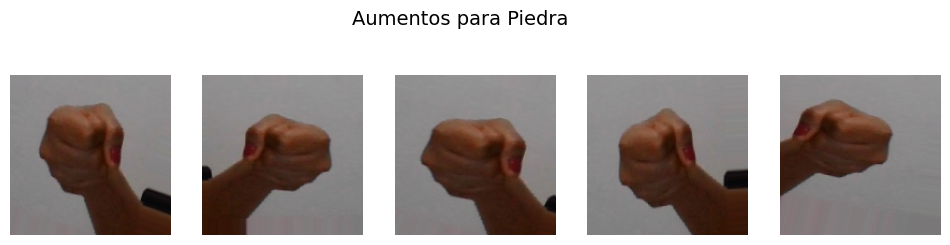

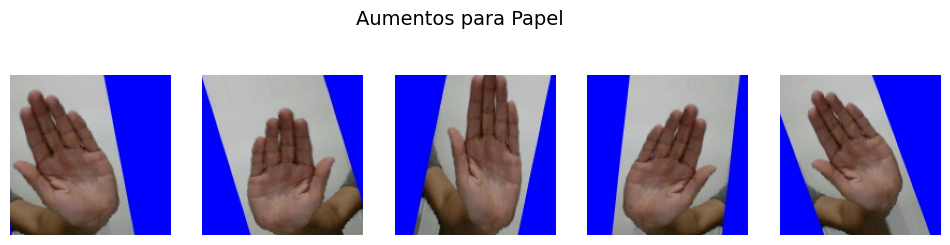

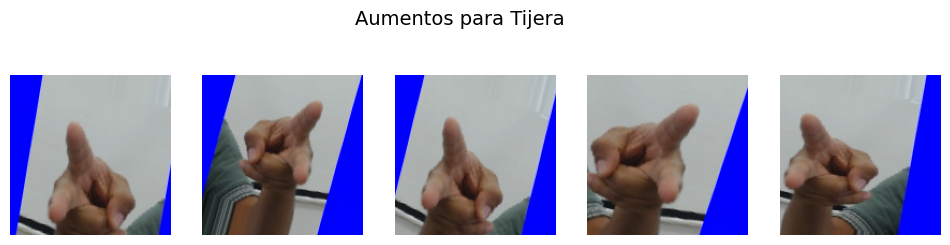

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# 1 Cargar las imágenes locales
imagenes = ['test/piedra.jpg', 'test/papel.jpg', 'test/tijera.jpg']
nombres = ['Piedra', 'Papel', 'Tijera']

# 2 Cargar y redimensionar imágenes (por ejemplo a 150x150)
X = [img_to_array(load_img(img, target_size=(150,150))) for img in imagenes]
X = np.array(X, dtype='float32') / 255.0  # Escalar a [0,1]

# 3 Definir el generador de aumentos
train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# 4 Generar aumentos por imagen individualmente
for i, (img, nombre) in enumerate(zip(X, nombres)):
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f"Aumentos para {nombre}", fontsize=14)

    # Crear un generador solo con UNA imagen
    img_array = np.expand_dims(img, axis=0)  # Añadir dimensión (batch de 1)
    single_generator = train_datagen.flow(img_array, batch_size=1)

    for j in range(5):
        aug_img = next(single_generator)[0]
        axes[j].imshow(aug_img)
        axes[j].axis('off')

    plt.show()
